In [2]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tabulate import tabulate

plt.style.use("../auri.mplstyle")

pd.options.display.unicode.east_asian_width = True

In [3]:
parquet_path = Path("../data/processed/주건축물_검증규칙.parquet")
df_orig = pd.read_parquet(parquet_path)
print(f"Loaded shape: {df_orig.shape}")
df_orig.head()

Loaded shape: (7364967, 38)


,관리_건축물대장_PK,관리_상위_건축물대장_PK,단독,대지_위치,시군구_코드,법정동_코드,주_용도_코드,주_용도_코드_명,기타_용도,대지_면적(㎡),...,건폐율_재계산,건폐율_차이,기존19,용적률_재계산,용적률_차이,기존20,신규01,연면적_상한,신규02,신규03
0,10021950,10021363,False,서울특별시 종로구 숭인동 201번지,11110,17500,01000,단독주택,주택,NaN,...,NaN,NaN,None,NaN,NaN,None,None,NaN,None,False
1,10021957,10021366,False,서울특별시 종로구 숭인동 569번지,11110,17500,02000,공동주택,아파트,513.0,...,44.409357,-0.009357,False,128.625731,152.414269,True,False,2107.74,False,False
2,10021958,10021366,False,서울특별시 종로구 숭인동 569번지,11110,17500,02000,공동주택,연립주택,NaN,...,NaN,NaN,None,NaN,NaN,None,None,NaN,None,False
3,10021973,10021373,False,서울특별시 종로구 숭인동 1132번지,11110,17500,04000,제2종근린생활시설,영업,NaN,...,NaN,NaN,None,NaN,NaN,None,None,NaN,None,False
4,10021974,10021373,False,서울특별시 종로구 숭인동 1132번지,11110,17500,04000,제2종근린생활시설,근린생활시설,NaN,...,NaN,NaN,None,NaN,NaN,None,None,NaN,None,False


In [4]:
con = duckdb.connect(database=":memory:")
query = """
SELECT
  *,
FROM
  df_orig
WHERE
  COALESCE("대지_면적(㎡)", "총괄_대지_면적(㎡)", 0) 
    >= COALESCE("건축_면적(㎡)", 0)                             -- not 기존14
  AND COALESCE("연면적(㎡)", 0) >= COALESCE("건축_면적(㎡)", 0) -- not 기존16
  AND COALESCE("연면적(㎡)", 0)                                 -- not 신규01
        >= COALESCE("용적_률_산정_연면적(㎡)", 0)
  AND COALESCE("대지_면적(㎡)", "총괄_대지_면적(㎡)", 0) >= 0   -- not 신규03
  AND COALESCE("건축_면적(㎡)", "총괄_건축_면적(㎡)", 0) >= 0
  AND COALESCE("연면적(㎡)", 0) >= 0
  AND COALESCE("지상_층_수", 0) >= 0
  AND COALESCE("지하_층_수", 0) >= 0
;
"""
rel = con.sql(query)
con.sql("SELECT COUNT(*) FROM rel").show()

# 검증규칙 확실히 통과한 건축물만 선택
df_filtered = rel.df()
with pd.option_context("display.max_columns", None):
    print(tabulate(df_filtered.head(), headers="keys", tablefmt="psql"))

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│      5085645 │
└──────────────┘

+----+----------------------+---------------------------+--------+-----------------------------------+---------------+---------------+----------------+-------------------+--------------+-----------------+-----------------+--------------+--------------+---------------------------+--------------+-----------+--------------+--------------+---------------+----------------------+----------------------+-------------------+-------------------+--------------------------------+-------------------+---------------------+----------+----------+-----------------+---------------+----------+-----------------+---------------+----------+----------+---------------+----------+----------+
|    |   관리_건축물대장_PK |   관리_상위_건축물대장_PK | 단독   | 대지_위치                         |   시군구_코드 |   법정동_코드 |   주_용도_코드 | 주_용도_코드_명   | 기타_용도    |   대지_면적(㎡) |   건축_면적(㎡) |   건폐_율(%) |   연면적(㎡) |   용적_률_산정_연면적(㎡) |   용적_률(%) |  

In [5]:
df_filtered.shape

(5085645, 38)

In [6]:
df_filtered.dtypes

관리_건축물대장_PK               object
관리_상위_건축물대장_PK          object
단독                               bool
대지_위치                        object
시군구_코드                      object
법정동_코드                      object
주_용도_코드                     object
주_용도_코드_명                  object
기타_용도                        object
대지_면적(㎡)                   float64
건축_면적(㎡)                   float64
건폐_율(%)                      float64
연면적(㎡)                      float64
용적_률_산정_연면적(㎡)         float64
용적_률(%)                      float64
높이(m)                         float64
지상_층_수                        int32
지하_층_수                        int32
사용승인_일                      object
총괄_대지_면적(㎡)              float64
총괄_건축_면적(㎡)              float64
총괄_건폐_율(%)                 float64
총괄_연면적(㎡)                 float64
총괄_용적_률_산정_연면적(㎡)    float64
총괄_용적_률(%)                 float64
총괄_주_건축물_수               float64
기존14                          boolean
기존16                          boolean
건폐율_재계산                

### 무차원 변수 산출

건축물의 규모에 비례하지 않는(무차원) 개별 건축물의 특성을 반영하는 변수를 산출하기 위하여 면적 관련 변수의 차원 분석을 시행.

| 이름                 | 차원         |
| -------------------- | ------------ |
| 대지면적             | [면적]       |
| 건축면적             | [면적]       |
| 연면적               | [면적][층수] |
| 용적률 산정용 연면적 | [면적][층수] |
| 지상 층수            | [층수]       |

<!-- | 건폐율               | [면적]/[면적] = [비율]             |
| 용적률               | [면적][층수]/[면적] = [비율][층수] | -->
<!-- | 지하 층수            | [층수]                             | -->

물리학의 차원분석은 길이, 질량 등을 다루며, 개수, 비율 등은 무차원수로 보나, 건축물 대상 차원분석에서는 건축법에 따라 건축물의 특성을 통제하는 변수인 면적, 층수, 비율 등을 별도의 차원으로 두었음.

1차적으로 비율 변수를 산출한 후, 각 비율 변수의 상관관계를 검토한 후 비례 관계가 나타나지 않는 무차원 변수를 최종 산출하고, 클러스터링 및 기계학습에 활용.

| 이름            | 정의                          | 차원                               |
| --------------- | ----------------------------- | ---------------------------------- |
| 건폐율 (재산출) | 건축면적/대지면적             | [면적]/[면적] = [비율]             |
| 용적률 (재산출) | 용적률 산정용 연면적/대지면적 | [면적][층수]/[면적] = [비율][층수] |
| 지상 유효층수   | 용적률 산정용 연면적/건축면적 | [면적][층수]/[면적] = [비율][층수] |
| 용적 산정률     | 용적률 산정용 연면적/연면적   | [면적][층수]/[면적][층수] = [비율] |

<!-- | 실질 용적률     | 연면적/대지면적               | [면적][층수]/[면적] = [비율][층수] |
| 유효층수        | 연면적/건축면적               | [면적][층수]/[면적] = [비율][층수] | -->

용적률, 유효층수 등 연면적이 적용된 비율 변수를 층수로 나누어 층별 비율 변수를 도출.

| 이름            | 정의                                   | 차원                              |
| --------------- | -------------------------------------- | --------------------------------- |
| 지상층별 건폐율 | 용적률 산정용 연면적/지상층수/대지면적 | [면적][층수]/층수/[면적] = [비율] |
| 지상층별 충만률 | 용적률 산정용 연면적/지상층수/건축면적 | [면적][층수]/층수/[면적] = [비율] |


In [7]:
# 우선 COALESCE 적용
대지면적 = df_filtered["대지_면적(㎡)"].fillna(df_filtered["총괄_대지_면적(㎡)"])
# 건축면적 = df_filtered["건축_면적(㎡)"].fillna(df_filtered["총괄_건축_면적(㎡)"])
지상층수 = df_filtered["지상_층_수"].fillna(0)
지하층수 = df_filtered["지하_층_수"].fillna(0)
총층수 = 지상층수 + 지하층수

df_dimensionless = pd.DataFrame(
    {
        "관리_건축물대장_PK": df_filtered["관리_건축물대장_PK"],
        "대지면적": 대지면적,
        "건축면적": df_filtered["건축_면적(㎡)"],
        "연면적": df_filtered["연면적(㎡)"],
        "용적률_산정용_연면적": df_filtered["용적_률_산정_연면적(㎡)"],
        "지상층수": 지상층수,
        "건폐율": df_filtered["건축_면적(㎡)"] / 대지면적,
        "용적률": df_filtered["용적_률_산정_연면적(㎡)"] / 대지면적,
        # "실질_용적률": df_filtered["연면적(㎡)"] / 대지면적,
        # "유효층수": df_filtered["연면적(㎡)"] / df_filtered["건축_면적(㎡)"],
        "지상_유효층수": df_filtered["용적_률_산정_연면적(㎡)"]
        / df_filtered["건축_면적(㎡)"],
        "용적_산정률": df_filtered["용적_률_산정_연면적(㎡)"]
        / df_filtered["연면적(㎡)"],
        # "층별_건폐율": df_filtered["연면적(㎡)"] / 총층수 / 대지면적,
        "지상층별_건폐율": df_filtered["용적_률_산정_연면적(㎡)"] / 지상층수 / 대지면적,
        # "층별_충만률": df_filtered["연면적(㎡)"]
        # / 총층수
        # / df_filtered["건축_면적(㎡)"],
        "지상층별_충만률": df_filtered["용적_률_산정_연면적(㎡)"]
        / 지상층수
        / df_filtered["건축_면적(㎡)"],
    }
)

# 무한대/NaN 정리
df_dimensionless = df_dimensionless.replace(
    [pd.NA, float("inf"), -float("inf")], np.nan
)
# df_dimensionless = df_dimensionless.fillna(-999)

In [8]:
df_dimensionless.dtypes

관리_건축물대장_PK       object
대지면적                float64
건축면적                float64
연면적                  float64
용적률_산정용_연면적    float64
지상층수                  int32
건폐율                  float64
용적률                  float64
지상_유효층수           float64
용적_산정률             float64
지상층별_건폐율         float64
지상층별_충만률         float64
dtype: object

In [9]:
with pd.option_context("display.float_format", "{:.4f}".format):
    display(df_dimensionless.describe())

,대지면적,건축면적,연면적,용적률_산정용_연면적,지상층수,건폐율,용적률,지상_유효층수,용적_산정률,지상층별_건폐율,지상층별_충만률
count,4827834.0000,4777956.0000,5081126.0000,4791078.0000,5085645.0000,4777956.0000,4724847.0000,4707543.0000,4791077.0000,4720271.0000,4703097.0000
mean,17015.6430,256.3988,815.2429,691.9291,2.3504,0.3080,0.6543,2.3107,0.9649,0.2739,0.9818
std,2346984.4250,1364.1303,60153.1923,38027.5603,3.1328,0.2223,3.1704,277.0266,0.0969,0.4277,56.2283
min,0.1200,0.0010,0.0010,-9.2400,0.0000,0.0000,-0.0280,0.0009,0.0001,-0.0093,0.0001
25%,244.4000,75.8500,85.9500,87.3800,1.0000,0.1188,0.1371,1.0000,1.0000,0.1078,0.8404
50%,495.0000,116.1300,178.8000,173.1000,1.0000,0.2521,0.3043,1.0000,1.0000,0.2278,1.0000
75%,1307.0000,199.5000,425.3100,404.4900,3.0000,0.5275,0.9516,2.0000,1.0000,0.4394,1.0000
max,4333333333.0000,2218284.2800,83374375.0000,58461732.0000,123.0000,1.0000,4946.7970,408459.3333,1.0000,549.6441,66603.0000


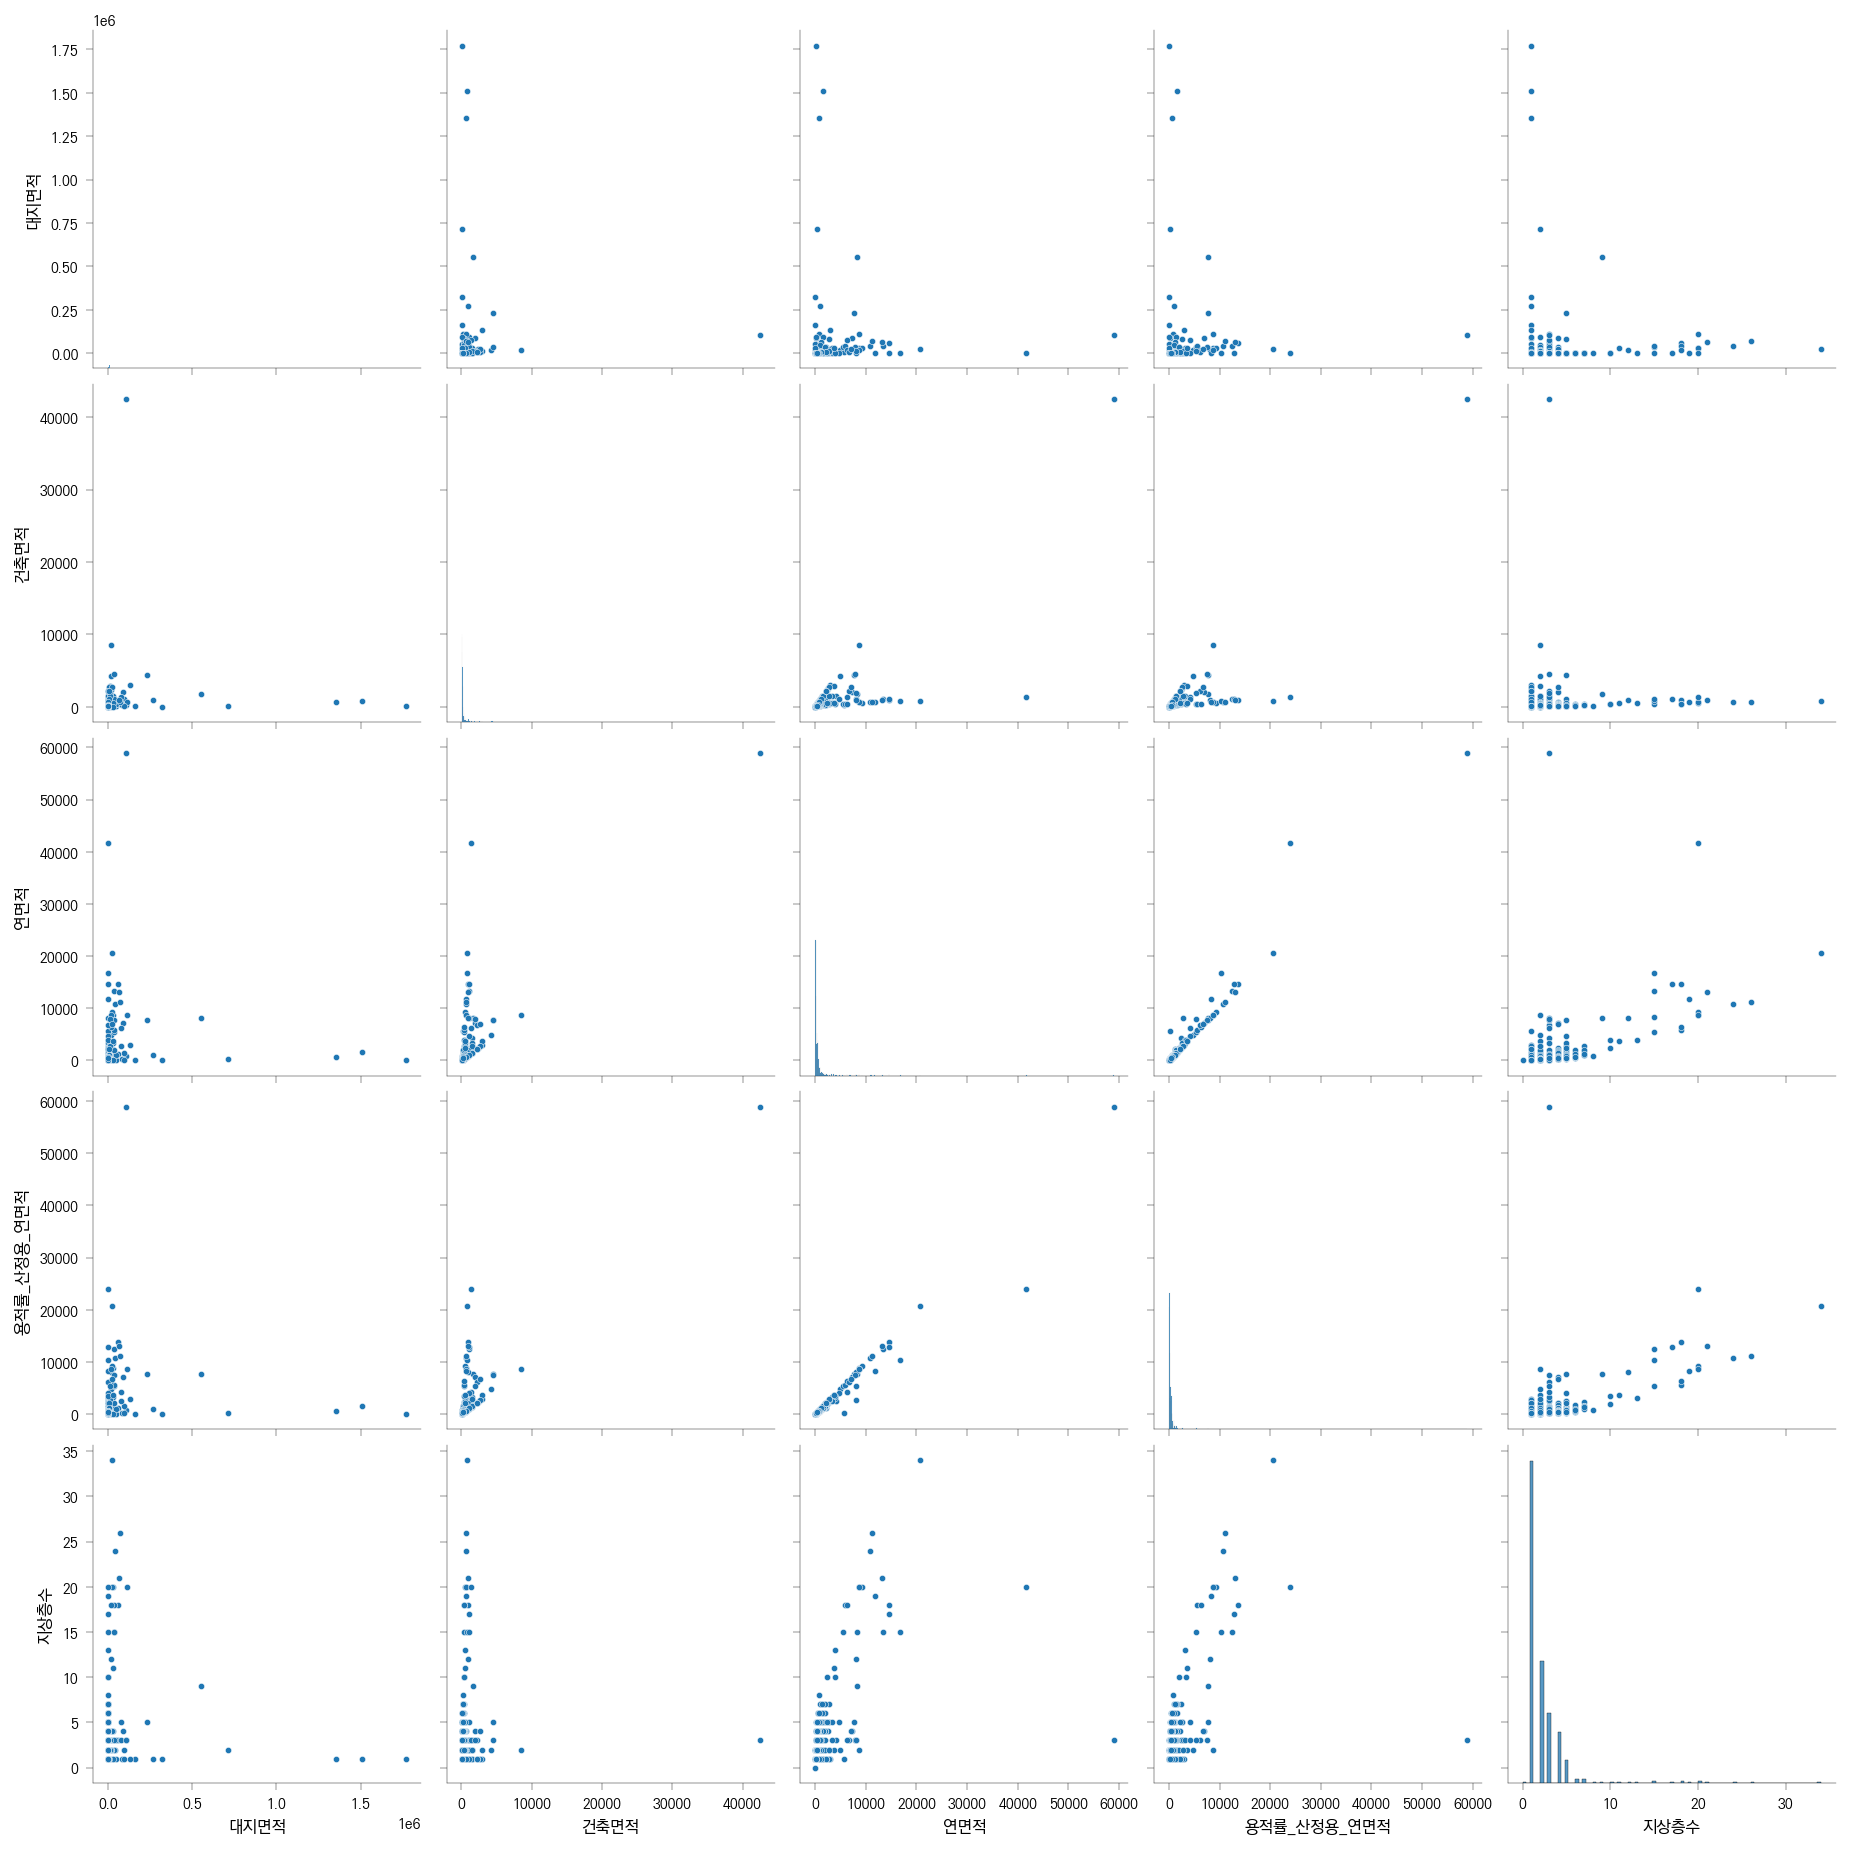

In [10]:
sampled = df_dimensionless.sample(n=1000, random_state=1106).copy()

sns.pairplot(sampled.iloc[:, :6])

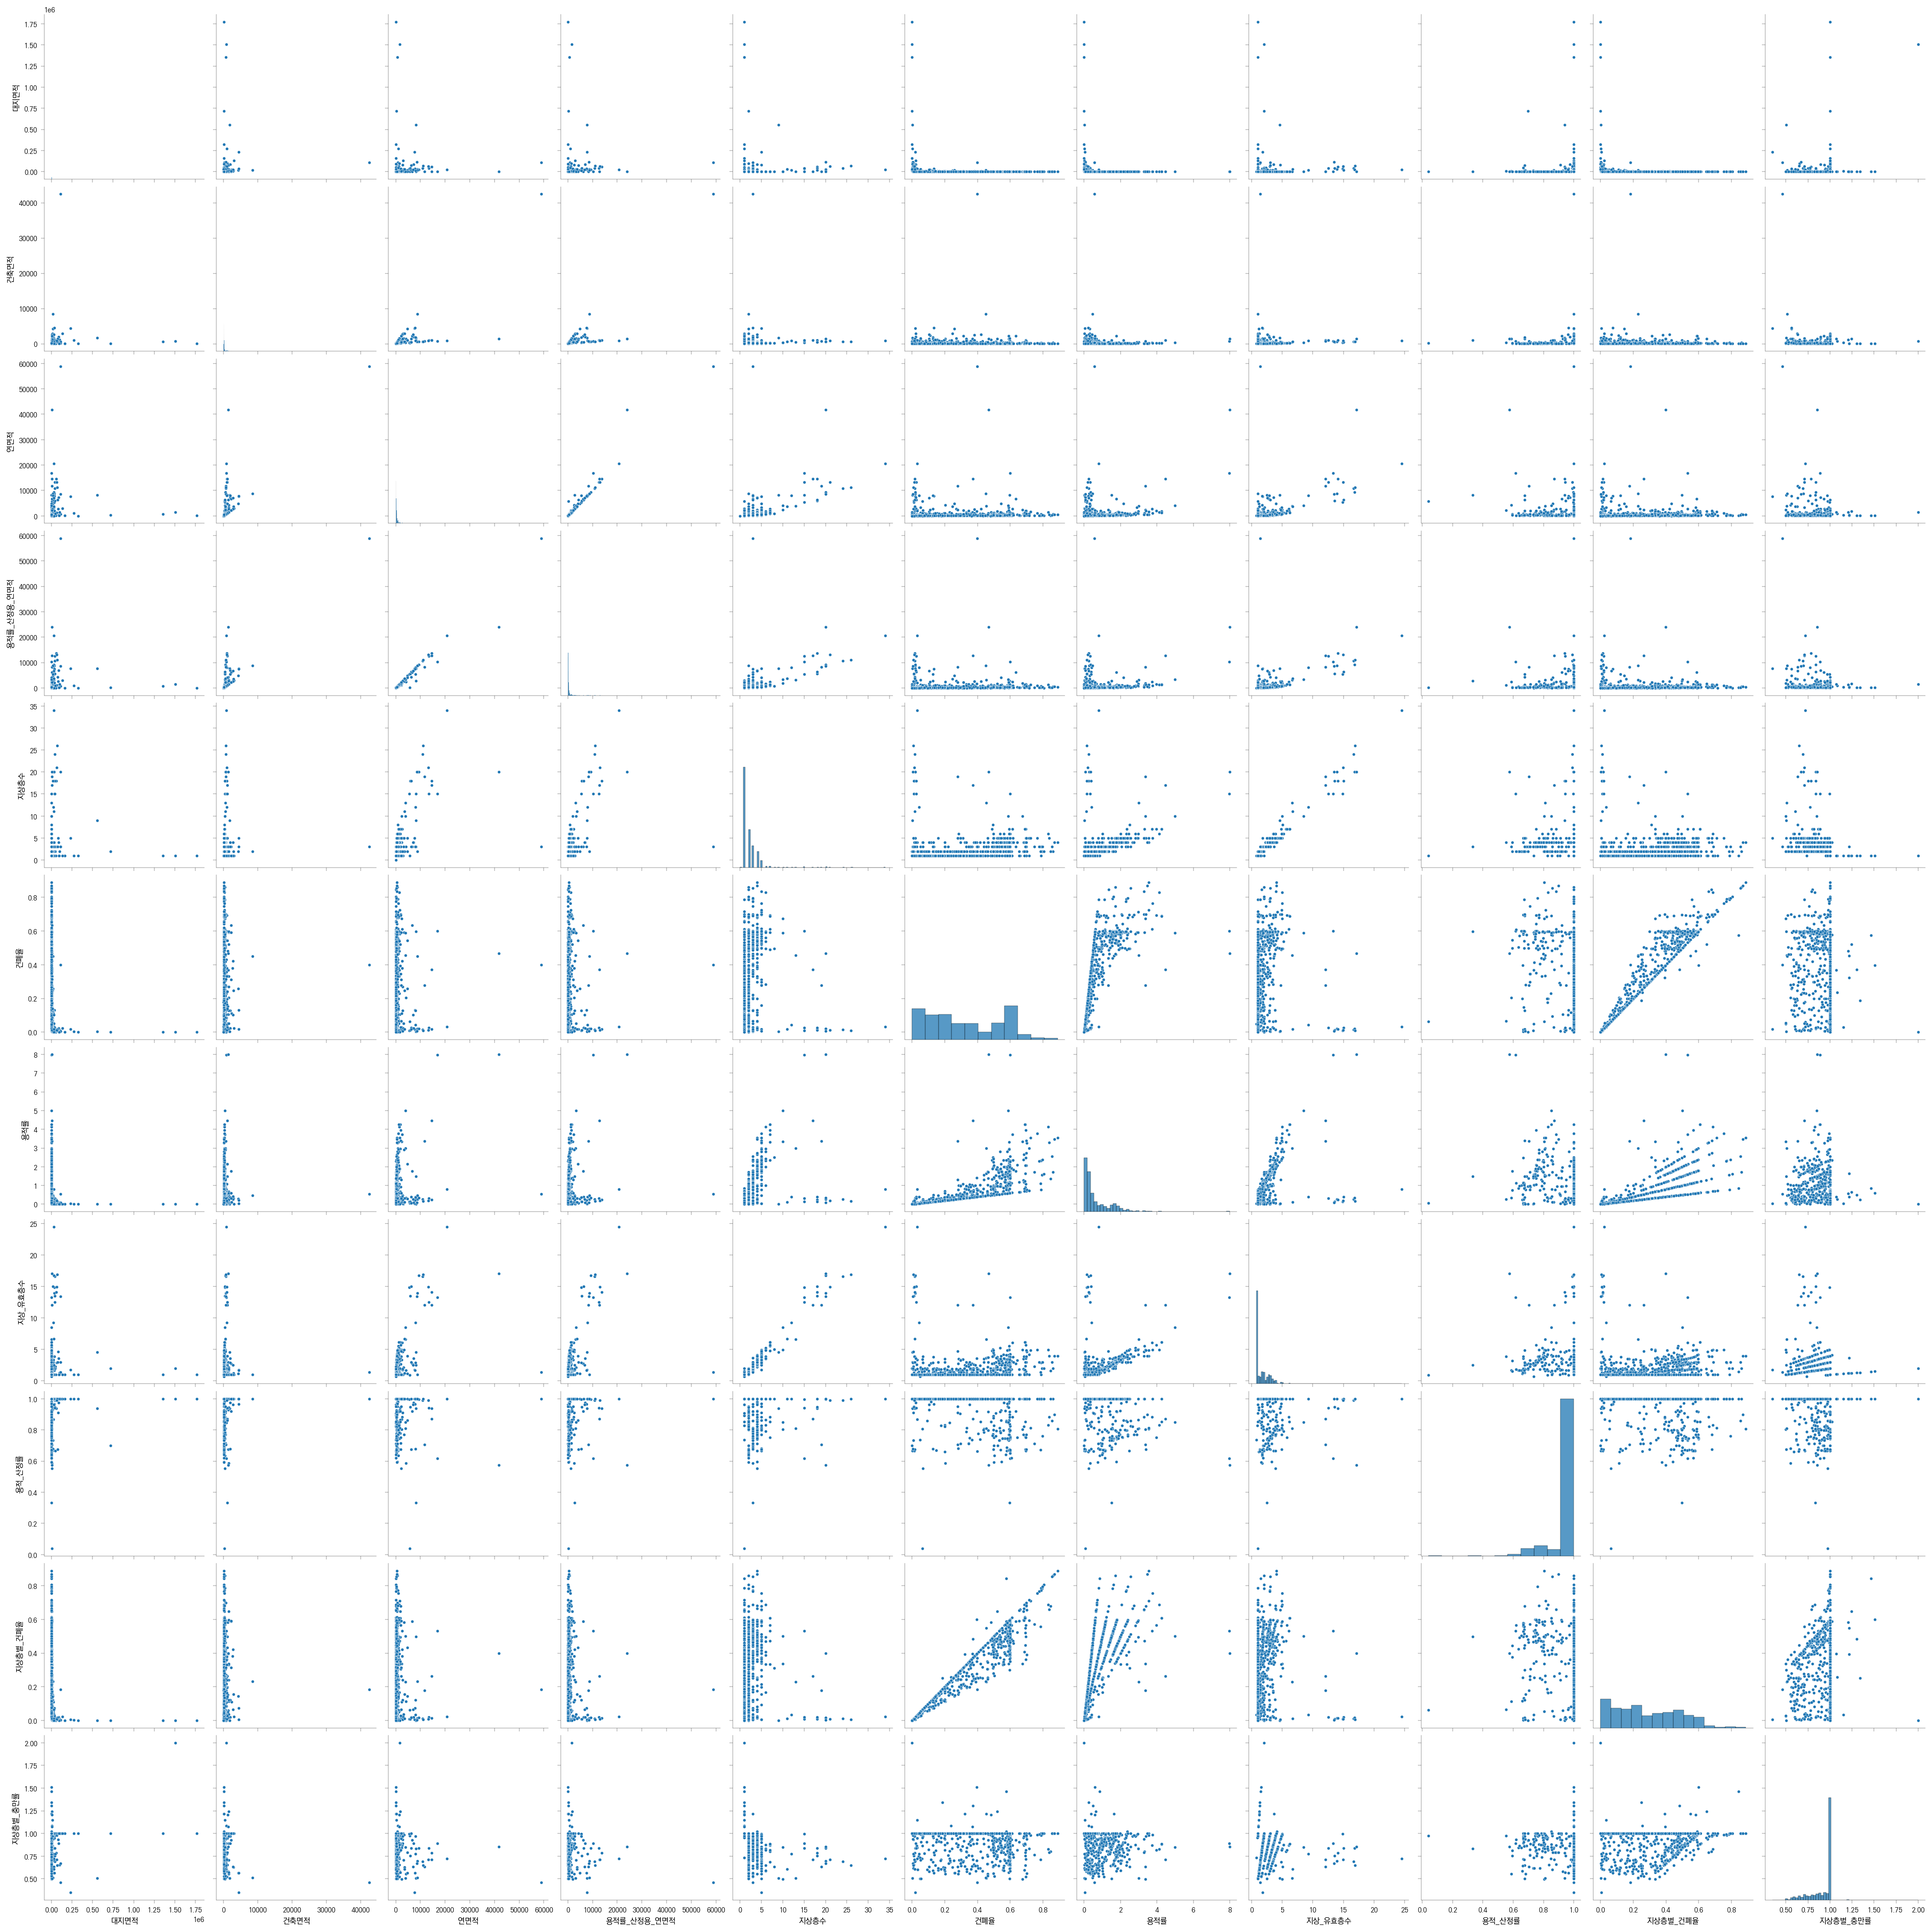

In [11]:
sns.pairplot(sampled)

### Anormaly Detection

Isolation Forest, One-Class SVM using SGD


In [12]:
df = (
    df_dimensionless.iloc[:, 6:12]
    .dropna()
    .sample(n=1_000_000, random_state=1106)
    .copy()
)

df.head()

,건폐율,용적률,지상_유효층수,용적_산정률,지상층별_건폐율,지상층별_충만률
4167674,0.000500,0.001998,4.000000,1.000000,0.000500,1.000000
322493,0.596386,1.633625,2.739210,1.000000,0.544542,0.913070
1975446,0.583846,0.583846,1.000000,1.000000,0.583846,1.000000
4849783,0.421825,0.576789,1.367366,1.000000,0.288394,0.683683
4732920,0.116342,0.196595,1.689799,0.583935,0.098298,0.844900


In [106]:
import time
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import SGDOneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import make_pipeline

# settings
outliers_fraction = 0.01

anomaly_algorithms = [
    (
        "One-Class SVM (SGD)",
        make_pipeline(
            Nystroem(gamma=0.1, random_state=1106, n_components=1_000),
            SGDOneClassSVM(
                nu=outliers_fraction,
                fit_intercept=True,
                random_state=1106,
            ),
        ),
    ),
    (
        "Isolation Forest",
        IsolationForest(contamination=outliers_fraction, random_state=1106),
    ),
]

# Choose sizes to test
sizes = [10_000, 20_000, 50_000, 100_000, 200_000]
results = []

for algo_name, clf in anomaly_algorithms:
    for n in sizes:
        X = df.sample(n=n, random_state=1106).to_numpy()

        start = time.perf_counter()
        clf.fit(X)
        elapsed = time.perf_counter() - start

        results.append((n, elapsed))
        print(f"clf={algo_name} n={n:<6}  time={elapsed:.4f} sec")


clf=One-Class SVM (SGD) n=10000   time=0.5675 sec
clf=One-Class SVM (SGD) n=20000   time=0.8020 sec
clf=One-Class SVM (SGD) n=50000   time=1.5288 sec
clf=One-Class SVM (SGD) n=100000  time=2.8174 sec
clf=One-Class SVM (SGD) n=200000  time=5.3054 sec
clf=Isolation Forest n=10000   time=0.1479 sec
clf=Isolation Forest n=20000   time=0.1958 sec
clf=Isolation Forest n=50000   time=0.3187 sec
clf=Isolation Forest n=100000  time=0.4866 sec
clf=Isolation Forest n=200000  time=1.0889 sec


In [17]:
import time
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import SGDOneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import make_pipeline

# settings
outliers_fraction = 0.01

X = df.to_numpy()

clf = IsolationForest(contamination=outliers_fraction, random_state=1106)
clf.fit(X)
y_pred = clf.predict(X)

# align by index when assigning back
df_dimensionless["pred_isolation_forest"] = pd.Series(y_pred, index=df.index)

In [18]:
clf = make_pipeline(
    Nystroem(gamma=0.1, random_state=1106, n_components=1_000),
    SGDOneClassSVM(
        nu=outliers_fraction,
        fit_intercept=True,
        random_state=1106,
    ),
)
clf.fit(X)
y_pred = clf.predict(X)

# align by index when assigning back
df_dimensionless["pred_one-class_svm"] = pd.Series(y_pred, index=df.index)

In [19]:
with pd.option_context("display.float_format", "{:.4f}".format):
    display(df_dimensionless.describe())

,대지면적,건축면적,연면적,용적률_산정용_연면적,지상층수,건폐율,용적률,지상_유효층수,용적_산정률,지상층별_건폐율,지상층별_충만률,pred_isolation_forest,pred_one-class_svm
count,4827834.0000,4777956.0000,5081126.0000,4791078.0000,5085645.0000,4777956.0000,4724847.0000,4707543.0000,4791077.0000,4720271.0000,4703097.0000,1000000.0000,1000000.0000
mean,17015.6430,256.3988,815.2429,691.9291,2.3504,0.3080,0.6543,2.3107,0.9649,0.2739,0.9818,0.9800,0.9804
std,2346984.4250,1364.1303,60153.1923,38027.5603,3.1328,0.2223,3.1704,277.0266,0.0969,0.4277,56.2283,0.1990,0.1970
min,0.1200,0.0010,0.0010,-9.2400,0.0000,0.0000,-0.0280,0.0009,0.0001,-0.0093,0.0001,-1.0000,-1.0000
25%,244.4000,75.8500,85.9500,87.3800,1.0000,0.1188,0.1371,1.0000,1.0000,0.1078,0.8404,1.0000,1.0000
50%,495.0000,116.1300,178.8000,173.1000,1.0000,0.2521,0.3043,1.0000,1.0000,0.2278,1.0000,1.0000,1.0000
75%,1307.0000,199.5000,425.3100,404.4900,3.0000,0.5275,0.9516,2.0000,1.0000,0.4394,1.0000,1.0000,1.0000
max,4333333333.0000,2218284.2800,83374375.0000,58461732.0000,123.0000,1.0000,4946.7970,408459.3333,1.0000,549.6441,66603.0000,1.0000,1.0000


In [20]:
stats = df_dimensionless.groupby("pred_isolation_forest")[
    [
        "대지면적",
        "건축면적",
        "연면적",
        "용적률_산정용_연면적",
        "지상층수",
        "건폐율",
        "용적률",
        "지상_유효층수",
        "용적_산정률",
        "지상층별_건폐율",
        "지상층별_충만률",
    ]
].agg(["count", "mean", "std", "min", "max"])
with pd.option_context(
    "display.float_format", "{:.4f}".format, "display.max_columns", None
):
    display(stats.T)


pred_isolation_forest            -1.0000       1.0000 
대지면적             count    10000.0000   990000.0000
                     mean     20321.5535    15781.2799
                     std     544549.8914   414260.7464
                     min         13.0000        4.0500
                     max   52367649.6000 73969796.9000
건축면적             count    10000.0000   990000.0000
                     mean      1026.2858      248.0319
                     std       2148.1526      910.2860
                     min          0.1000        0.2200
                     max      58217.8000   242035.1200
연면적               count    10000.0000   990000.0000
                     mean     14673.9969      640.7211
                     std     168613.9712     3265.7075
                     min         17.3400        0.2200
                     max   12427255.0000  2069605.0000
용적률_산정용_연면적 count    10000.0000   990000.0000
                     mean      7590.0703      597.4808
                     std      13649.6021     2035.1796
                     min          1.0000        0.2200
                     max     323149.8700   444671.6500
지상층수             count    10000.0000   990000.0000
                     mean        10.9050        2.3038
                     std          8.2756        2.9851
                     min          1.0000        1.0000
                     max        101.0000       58.0000
건폐율               count    10000.0000   990000.0000
                     mean         0.5416        0.3034
                     std          0.2800        0.2198
                     min          0.0000        0.0000
                     max          1.0000        1.0000
용적률               count    10000.0000   990000.0000
                     mean         3.9642        0.6162
                     std          2.6277        0.7026
                     min          0.0000        0.0000
                     max         16.4069        5.3337
지상_유효층수        count    10000.0000   990000.0000
                     mean        43.6206        1.9367
                     std       3494.1994        2.1591
                     min          0.0009        0.5000
                     max     349426.5800       44.9155
용적_산정률          count    10000.0000   990000.0000
                     mean         0.7241        0.9679
                     std          0.2277        0.0909
                     min          0.0001        0.0002
                     max          1.0000        1.0000
지상층별_건폐율      count    10000.0000   990000.0000
                     mean         0.4418        0.2713
                     std          0.2997        0.1965
                     min          0.0000        0.0000
                     max          3.3871        2.3706
지상층별_충만률      count    10000.0000   990000.0000
                     mean         2.3567        0.9165
                     std        134.5205        0.1601
                     min          0.0001        0.0362
                     max      13439.4838       18.1212

In [21]:
stats = df_dimensionless.groupby("pred_one-class_svm")[
    [
        "대지면적",
        "건축면적",
        "연면적",
        "용적률_산정용_연면적",
        "지상층수",
        "건폐율",
        "용적률",
        "지상_유효층수",
        "용적_산정률",
        "지상층별_건폐율",
        "지상층별_충만률",
    ]
].agg(["count", "mean", "std", "min", "max"])
with pd.option_context(
    "display.float_format", "{:.4f}".format, "display.max_columns", None
):
    display(stats.T)


pred_one-class_svm               -1.0000       1.0000 
대지면적             count     9797.0000   990203.0000
                     mean     73335.2599    15257.6968
                     std     766046.4798   410771.0945
                     min          4.0500        4.4440
                     max   40704700.0000 73969796.9000
건축면적             count     9797.0000   990203.0000
                     mean       766.0577      250.7661
                     std       1393.6946      926.9771
                     min          0.1000        0.2200
                     max      35784.7000   242035.1200
연면적               count     9797.0000   990203.0000
                     mean     12568.6101      664.4286
                     std     114577.3631    12979.2271
                     min          4.0500        0.2200
                     max    8444653.0000 12427255.0000
용적률_산정용_연면적 count     9797.0000   990203.0000
                     mean      8479.8211      590.1112
                     std      12223.8008     2103.1594
                     min          1.0000        0.2200
                     max     323149.8700   444671.6500
지상층수             count     9797.0000   990203.0000
                     mean        15.3155        2.2620
                     std         10.7751        2.7427
                     min          1.0000        1.0000
                     max        101.0000       52.0000
건폐율               count     9797.0000   990203.0000
                     mean         0.3099        0.3057
                     std          0.3536        0.2201
                     min          0.0000        0.0000
                     max          1.0000        1.0000
용적률               count     9797.0000   990203.0000
                     mean         2.4221        0.6321
                     std          3.0142        0.7443
                     min          0.0000        0.0000
                     max         16.4069        6.9970
지상_유효층수        count     9797.0000   990203.0000
                     mean        47.8032        1.9039
                     std       3530.1825        1.9758
                     min          0.0009        0.4607
                     max     349426.5800       20.4226
용적_산정률          count     9797.0000   990203.0000
                     mean         0.8588        0.9665
                     std          0.2213        0.0937
                     min          0.0001        0.0002
                     max          1.0000        1.0000
지상층별_건폐율      count     9797.0000   990203.0000
                     mean         0.2816        0.2730
                     std          0.3726        0.1961
                     min          0.0000        0.0000
                     max          3.3871        1.2684
지상층별_충만률      count     9797.0000   990203.0000
                     mean         2.5281        0.9151
                     std        135.9077        0.1398
                     min          0.0001        0.0391
                     max      13439.4838        2.2812

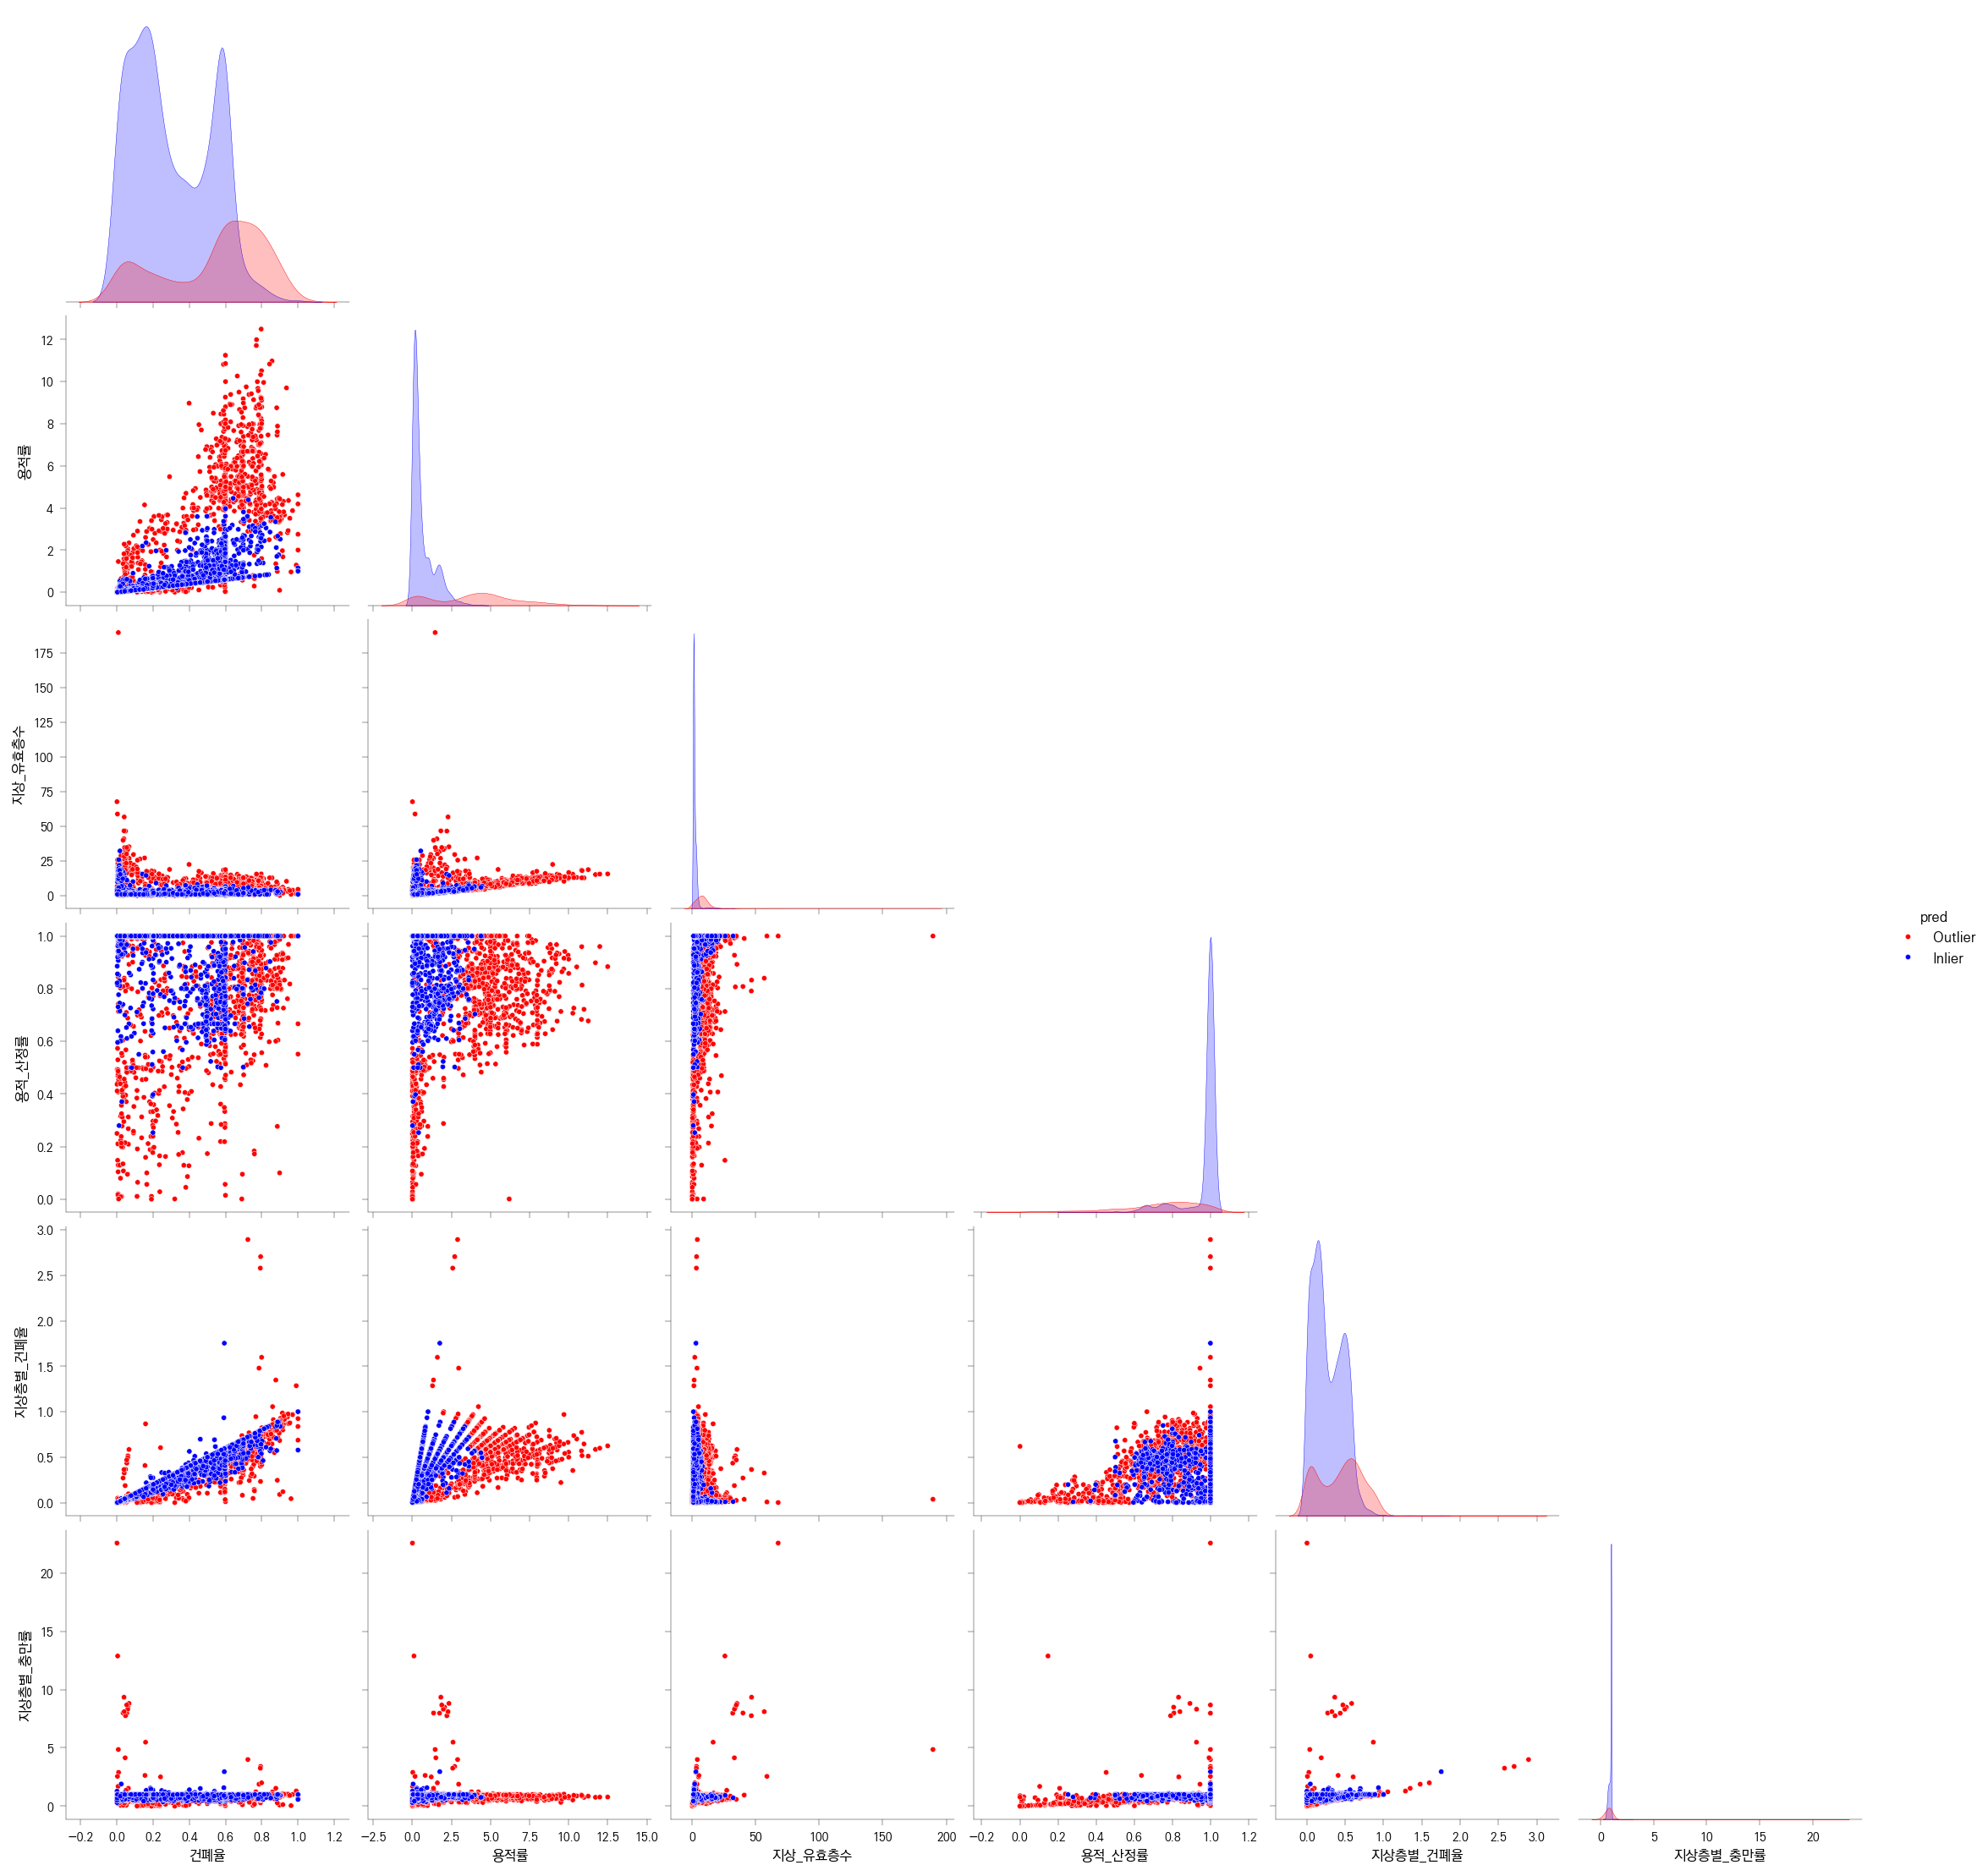

In [27]:
outliers = df_dimensionless[df_dimensionless["pred_isolation_forest"] == -1]
inliers = df_dimensionless[df_dimensionless["pred_isolation_forest"] == 1]

# Choose how many to keep
n_out = min(len(outliers), 1000)  # keep up to 1k outliers
n_in = min(len(inliers), 3000)  # keep up to 3k inliers

out_sample = outliers.sample(n=n_out, random_state=42)
in_sample = inliers.sample(n=n_in, random_state=42)

plot_df = pd.concat([out_sample, in_sample])
# Attach only the features + prediction
plot_df = plot_df.iloc[:, 6:12].assign(pred=plot_df["pred_isolation_forest"])
# Map labels
plot_df["pred"] = plot_df["pred"].map({-1: "Outlier", 1: "Inlier"})

sns.pairplot(
    plot_df, hue="pred", corner=True, palette={"Outlier": "red", "Inlier": "blue"}
)

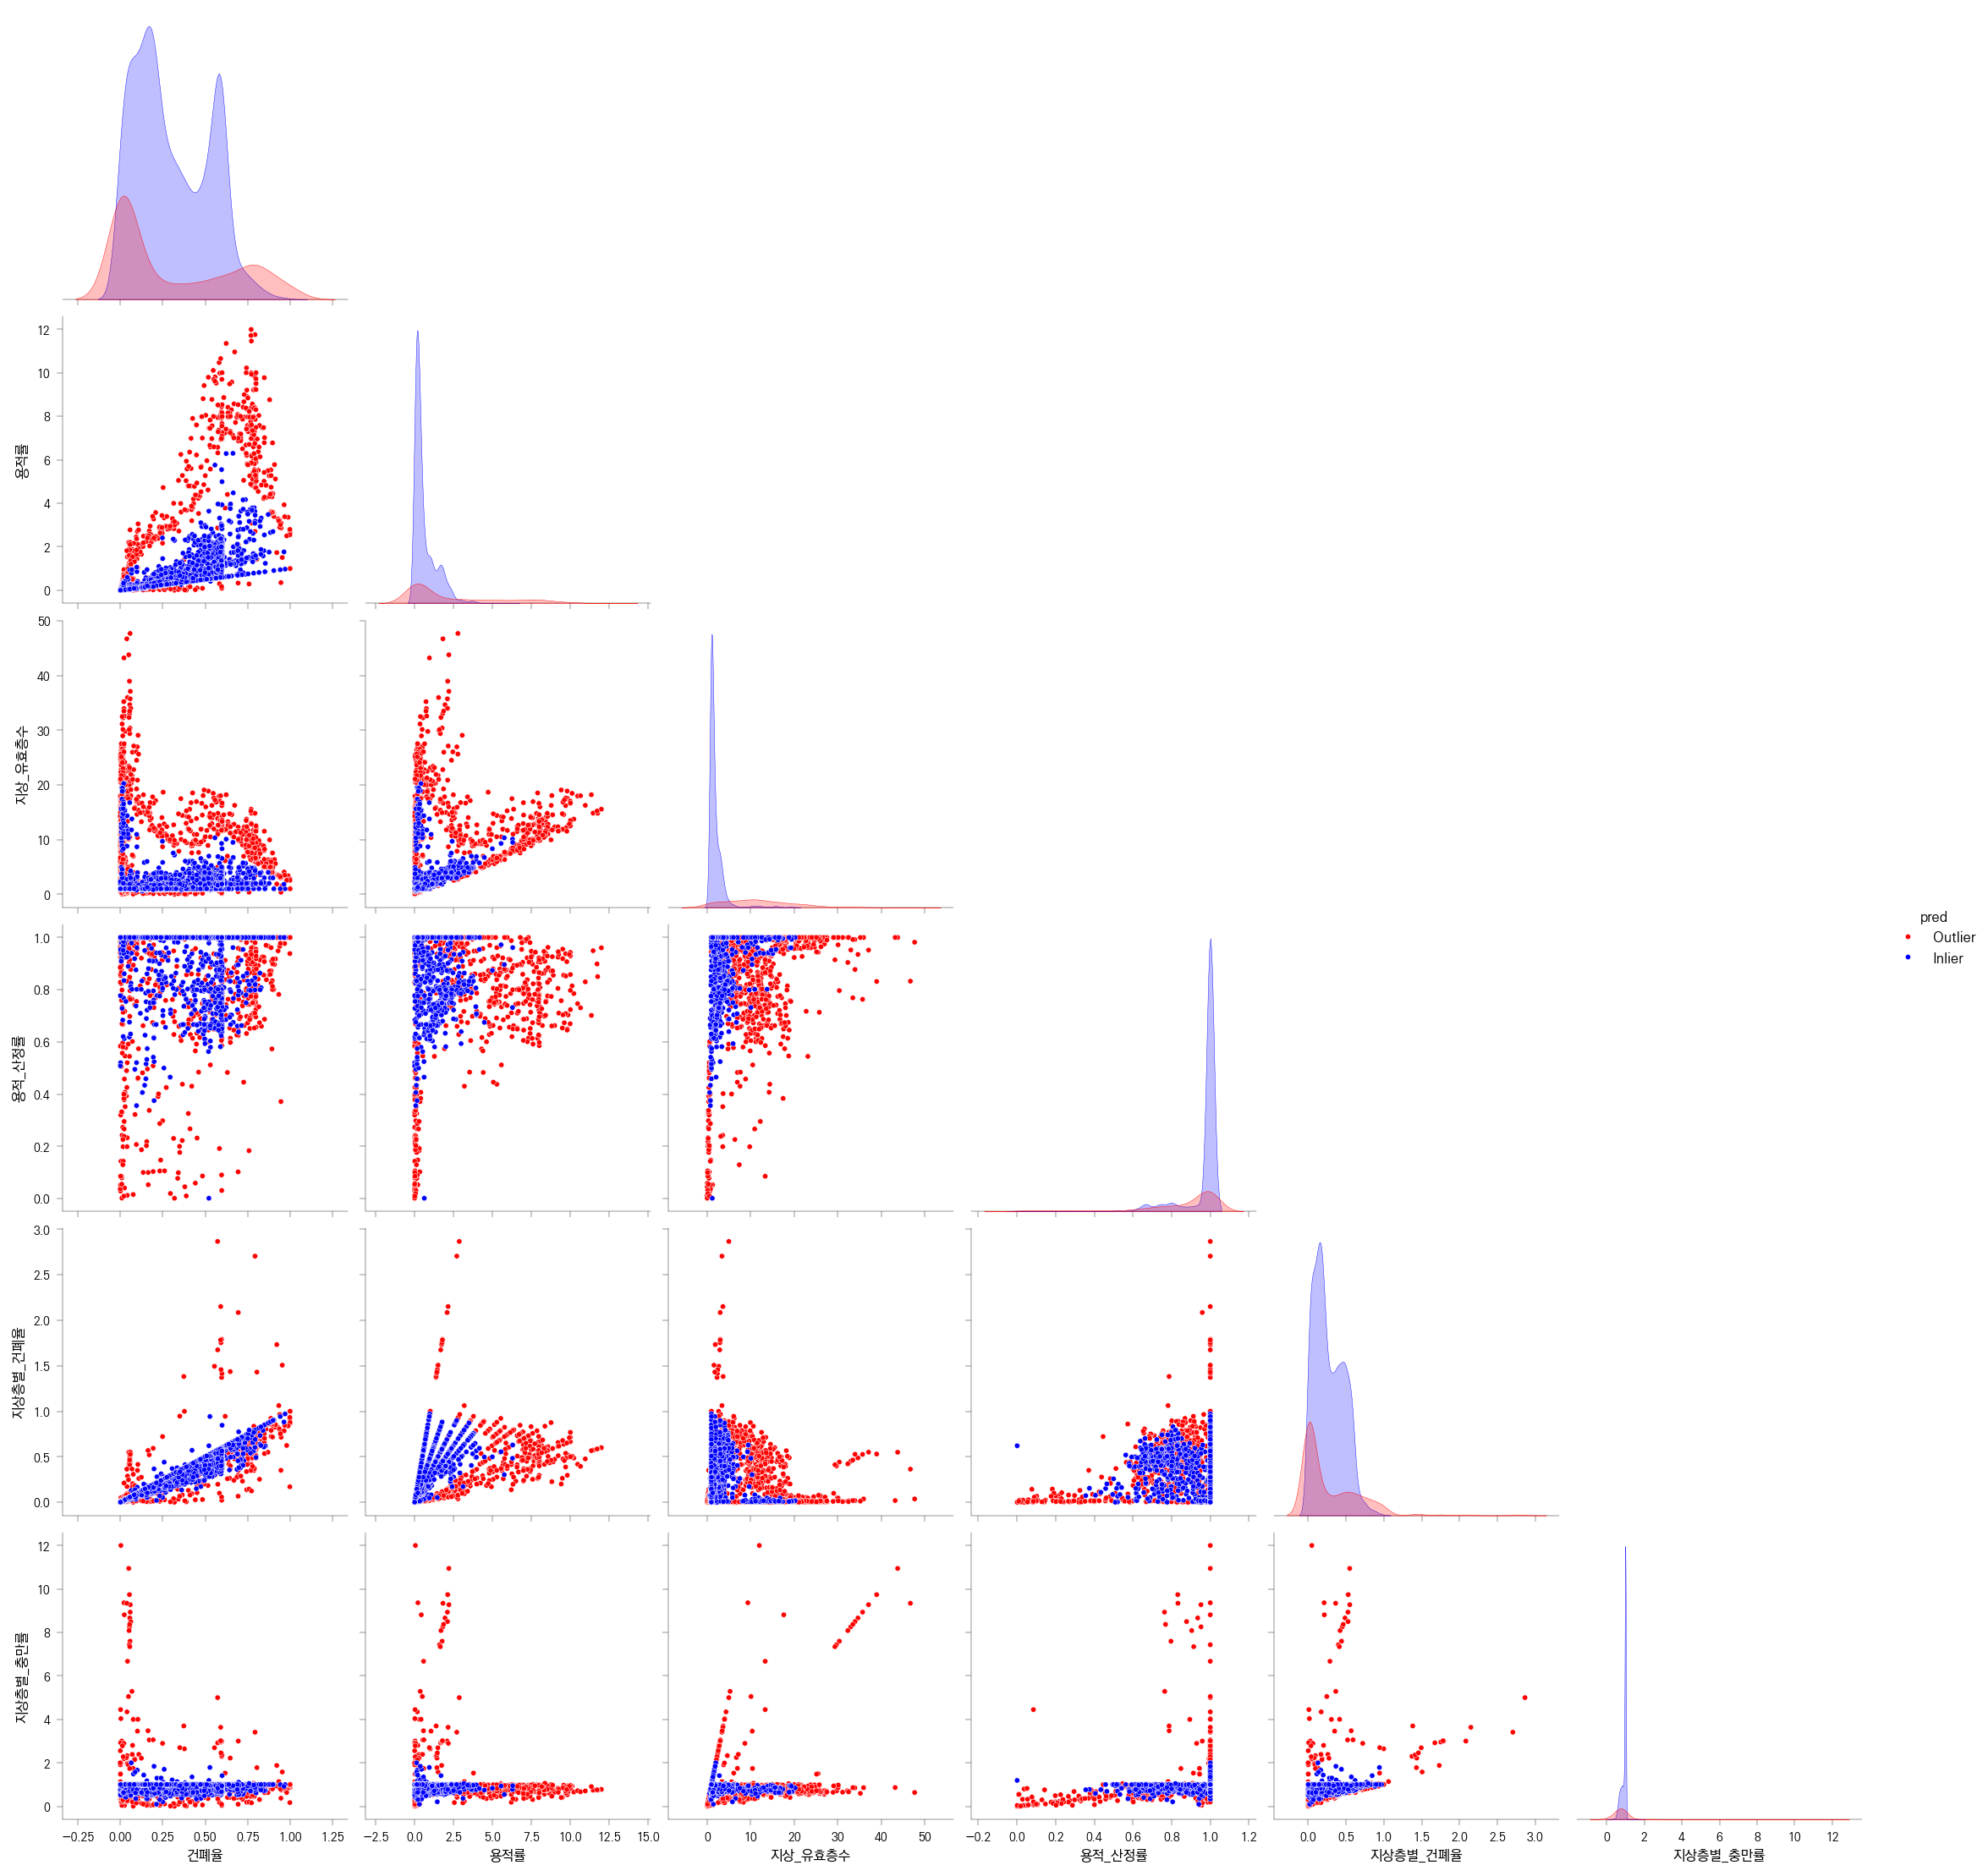

In [28]:
pred_column = "pred_one-class_svm"

outliers = df_dimensionless[df_dimensionless[pred_column] == -1]
inliers = df_dimensionless[df_dimensionless[pred_column] == 1]

# Choose how many to keep
n_out = min(len(outliers), 1000)  # keep up to 1k outliers
n_in = min(len(inliers), 3000)  # keep up to 3k inliers

out_sample = outliers.sample(n=n_out, random_state=42)
in_sample = inliers.sample(n=n_in, random_state=42)

plot_df = pd.concat([out_sample, in_sample])
# Attach only the features + prediction
plot_df = plot_df.iloc[:, 6:12].assign(pred=plot_df[pred_column])
# Map labels
plot_df["pred"] = plot_df["pred"].map({-1: "Outlier", 1: "Inlier"})

sns.pairplot(
    plot_df, hue="pred", corner=True, palette={"Outlier": "red", "Inlier": "blue"}
)

### K-means

빅데이터이므로 MiniBatchKMeans 사용.

elbow 방법으로 적절한 클러스터 개수(K) 탐색.


In [14]:
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.utils import check_random_state


def minibatch_inertia_curve(
    X, ks, *, batch_size=2048, random_state=0, repeats=3, max_iter=100
):
    rng = check_random_state(random_state)
    inertias = []
    for k in ks:
        vals = []
        for r in range(repeats):
            mbk = MiniBatchKMeans(
                n_clusters=k,
                random_state=rng.randint(0, 2**31 - 1),
                batch_size=batch_size,
                max_iter=max_iter,
                n_init="auto",
            )
            mbk.fit(X)
            vals.append(mbk.inertia_)
        inertias.append(float(np.median(vals)))
    return np.asarray(inertias)


def kneedle_elbow(ks, inertias):
    # Normalize to [0,1] and flip so larger is better
    x = (np.array(ks) - ks[0]) / (ks[-1] - ks[0])
    y = (inertias.max() - inertias) / (inertias.max() - inertias.min() + 1e-12)

    # Line between endpoints: y = x  (after the above normalization)
    # Distance from each point to the line
    d = (y - x) / np.sqrt(2.0)
    idx = int(np.argmax(d))
    return ks[idx], idx, d


In [15]:
df_dimensionless.columns

Index(['관리_건축물대장_PK', '건폐율', '층별_용적률', '지상층별_용적률',
       '충만률'], dtype='object')

In [16]:
### null 제거. 제거하지 않았더니 null인 것과 아닌 것만 클러스터로 잡힘.

X = (
    df_dimensionless[["건폐율", "층별_용적률", "지상층별_용적률", "충만률"]]
    .dropna()
    .to_numpy()
)

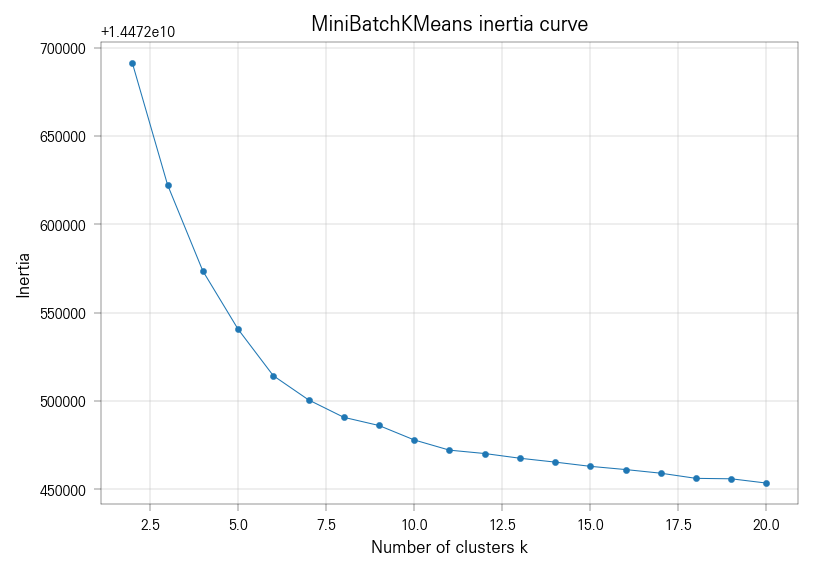

In [17]:
ks = np.arange(2, 21)  # pick a sensible range
inertias = minibatch_inertia_curve(X, ks, batch_size=2048, repeats=5)
plt.figure(figsize=(6, 4))
plt.plot(ks, inertias, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.title("MiniBatchKMeans inertia curve")
plt.grid(True)
plt.show()


In [18]:
k_star, idx, _ = kneedle_elbow(ks, inertias)
print("Elbow at k =", k_star)

Elbow at k = 7


7개가 적절한 것으로 판단됨.


In [19]:
feature_names = ["건폐율", "층별_용적률", "지상층별_용적률", "충만률"]
k = 7  # from above elbow analysis

km = MiniBatchKMeans(
    n_clusters=k,
    random_state=1106,
).fit(X)

labels = km.labels_
inertia = float(km.inertia_)
sizes = np.bincount(labels, minlength=k)

# centers in original feature scale
centers = km.cluster_centers_
centers_df = pd.DataFrame(
    centers, columns=feature_names, index=[f"cluster_{i}" for i in range(k)]
)

# ---- per-cluster stats (original scale) ----
df_results = pd.DataFrame(X, columns=feature_names)
df_results["_cluster"] = labels

means = df_results.groupby("_cluster").mean(numeric_only=True)
stds = df_results.groupby("_cluster").std(numeric_only=True, ddof=0)
mins = df_results.groupby("_cluster").min(numeric_only=True)
maxs = df_results.groupby("_cluster").max(numeric_only=True)

print("=== MiniBatchKMeans (k=4) Summary ===")
print(f"Inertia: {inertia:,.3f}")
print("Cluster sizes:", dict((f"cluster_{i}", int(sizes[i])) for i in range(k)))
print("\nCluster centers (original scale):")
print(centers_df.round(4))
print("\nPer-cluster means (original scale):")
print(means.add_prefix("mean_").round(4))
print("\nPer-cluster stds (original scale):")
print(stds.add_prefix("std_").round(4))
print("\nPer-cluster mins / maxs (original scale):")
print(mins.add_prefix("min_").round(4))
print(maxs.add_prefix("max_").round(4))

=== MiniBatchKMeans (k=4) Summary ===
Inertia: 14,472,507,193.457
Cluster sizes: {'cluster_0': 1159427, 'cluster_1': 970548, 'cluster_2': 1182210, 'cluster_3': 166048, 'cluster_4': 242710, 'cluster_5': 321865, 'cluster_6': 543817}

Cluster centers (original scale):
           건폐율  층별_용적률  지상층별_용적률  충만률
cluster_0  0.2313       0.2278           0.2290  0.9910
cluster_1  0.5363       0.5079           0.5103  0.9554
cluster_2  0.0650       0.0644           0.0645  0.9922
cluster_3  0.7564       0.7044           0.7067  0.9363
cluster_4  0.0550       0.0368           0.0364  0.6765
cluster_5  0.2564       0.1701           0.1693  0.6707
cluster_6  0.5384       0.3985           0.3986  0.7495

Per-cluster means (original scale):
          mean_건폐율  mean_층별_용적률  mean_지상층별_용적률  mean_충만률
_cluster                                                                  
0              0.2370            0.2333                0.2346       0.9911
1              0.5363            0.5058                0.508

In [20]:
from sklearn.neighbors import LocalOutlierFactor

# sampled = df.sample(n=10_000, replace=False, random_state=1106)
# X = sampled[["연면적(㎡)", "용적_률(%)"]].dropna().values

# X_train, X_test = train_test_split(X, test_size=0.2, random_state=1106)

clf = LocalOutlierFactor()
y_pred = clf.fit_predict(X)
unique, counts = np.unique(y_pred, return_counts=True)
print(dict(zip(unique, counts)))

df_results["_lof"] = y_pred

{np.int64(-1): np.int64(240529), np.int64(1): np.int64(4346096)}


c:\Users\USER\Documents\quacklytics\.venv\Lib\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


In [21]:
means = df_results.groupby(["_cluster", "_lof"]).mean(numeric_only=True)
print("\nPer-cluster means (original scale):")
print(means.add_prefix("mean_").round(4))

counts = df_results.groupby(["_cluster", "_lof"]).size()
# pivot so _cluster is rows, _lof is columns
pivot = counts.unstack(fill_value=0)
print("\nPer-cluster means (original scale):")
print(pivot.round(4))


Per-cluster means (original scale):
               mean_건폐율  mean_층별_용적률  mean_지상층별_용적률  \
_cluster _lof                                                        
0        -1         0.2310            0.2295                0.2297   
          1         0.2374            0.2336                0.2350   
1        -1         0.5231            0.5006                0.5028   
          1         0.5369            0.5061                0.5089   
2        -1         0.0790            0.0787                0.0787   
          1         0.0671            0.0664                0.0666   
3        -1         0.7740            0.7268                0.7311   
          1         0.7563            0.7049                0.7082   
4        -1         0.0574            0.0395                0.0377   
          1         0.0599            0.0394                0.0394   
5        -1         0.2711            0.1774                0.1756   
          1         0.2669            0.1761                0.1763  

In [22]:
def stratified_sample(df, stratum_col, n, min_per_stratum=5, random_state=1106):
    counts = df[stratum_col].value_counts()
    N = counts.sum()
    # proportional allocation
    alloc = (n * counts / N).round().astype(int).clip(lower=min_per_stratum)
    # cap by available rows
    alloc = np.minimum(alloc, counts)
    # draw
    parts = []
    rng = np.random.default_rng(random_state)
    for h, k in alloc.items():
        grp = df[df[stratum_col] == h]
        parts.append(grp.sample(n=k, random_state=rng.integers(0, 1 << 32)))
    out = pd.concat(parts, ignore_index=True)
    return out


# usage
# df['stratum'] = pd.qcut(df['x'], q=20, duplicates='drop')  # if stratifying by quantiles
# sampled = stratified_sample(df, "label", n=10_000)

In [23]:
# sampled = stratified_sample(df_results, "_lof", n=1_000, min_per_stratum=100)
sampled = df_results.sample(n=1_000, random_state=1106).copy()

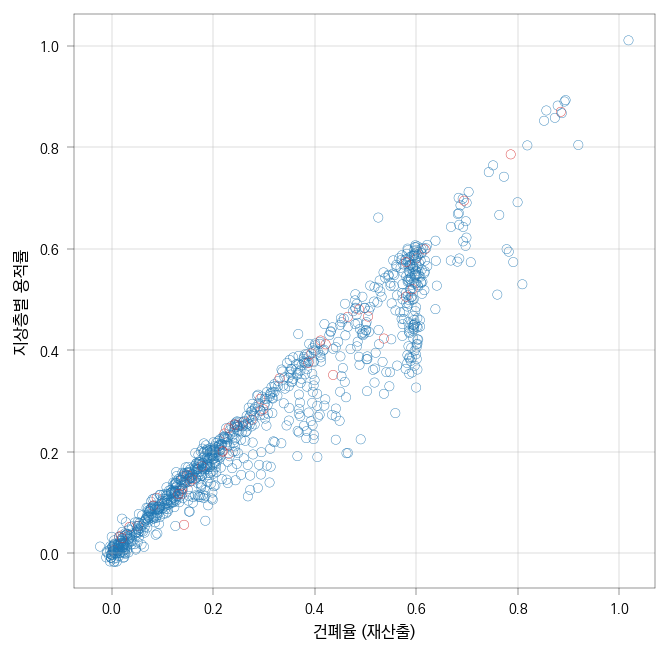

In [24]:
plt.figure(figsize=(5, 5))
colors = sampled["_lof"].map({-1: "tab:red", 1: "tab:blue"})

# Add jitter
jitter_strength_x = 0.01  # adjust based on scale of 건폐율
jitter_strength_y = 0.01  # adjust based on scale of 지상층별 용적률
x = sampled["건폐율"] + np.random.normal(0, jitter_strength_x, len(sampled))
y = sampled["지상층별_용적률"] + np.random.normal(0, jitter_strength_y, len(sampled))

# Scatterplot
plt.scatter(
    x,
    y,
    edgecolors=colors,
    facecolors="none",
    s=20,
)

plt.gca().set_aspect("equal")
plt.xlabel("건폐율 (재산출)")
plt.ylabel("지상층별 용적률")
plt.grid(True)

---


### OPTICS

DBSCAN과 유사한 알고리즘이나 메모리 소요량이 더 적음.


In [ ]:
from sklearn.cluster import OPTICS

cls = OPTICS().fit(X)

In [ ]:
def describe_optics(
    cls, X, feature_names=None, sample_for_silhouette=100_000, random_state=0
):
    """
    Summarize OPTICS result after cls = OPTICS(...).fit(X).

    - Counts clusters (excl. noise).
    - Reports size of each label (noise = -1).
    - Gives per-cluster means of features.
    """
    labels = cls.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    if feature_names is None:
        feature_names = [f"f{i}" for i in range(X.shape[1])]

    # Sizes including noise
    unique, counts = np.unique(labels, return_counts=True)
    sizes = dict(zip(unique.tolist(), counts.tolist()))

    # Per-cluster means (excluding noise)
    df = pd.DataFrame(X, columns=feature_names)
    df["_cluster"] = labels
    means = df[df["_cluster"] != -1].groupby("_cluster").mean(numeric_only=True)

    print("=== OPTICS Summary ===")
    print(f"Clusters found (excluding noise): {n_clusters}")
    print("Cluster sizes (label -1=noise):", sizes)
    if n_clusters > 0:
        print("\nPer-cluster means (original scale):")
        print(means.round(4))

    return {
        "labels": labels,
        "n_clusters": n_clusters,
        "sizes": sizes,
        "means": means,
    }


summary = describe_optics(cls, X, feature_names=feature_names)

---


In [ ]:
# simple sampling

# sampled = df.sample(n=10_000, replace=False, random_state=1106)

In [ ]:
def stratified_sample(df, stratum_col, n, min_per_stratum=5, random_state=1106):
    counts = df[stratum_col].value_counts()
    N = counts.sum()
    # proportional allocation
    alloc = (n * counts / N).round().astype(int).clip(lower=min_per_stratum)
    # cap by available rows
    alloc = np.minimum(alloc, counts)
    # draw
    parts = []
    rng = np.random.default_rng(random_state)
    for h, k in alloc.items():
        grp = df[df[stratum_col] == h]
        parts.append(grp.sample(n=k, random_state=rng.integers(0, 1 << 32)))
    out = pd.concat(parts, ignore_index=True)
    return out


# usage
# df['stratum'] = pd.qcut(df['x'], q=20, duplicates='drop')  # if stratifying by quantiles
# sampled = stratified_sample(df, "label", n=10_000)

In [ ]:
df["건축_면적_이상"] = df["건축_면적(㎡)"] > df["대지_면적(㎡)"]

sampled = stratified_sample(df, "건축_면적_이상", n=10_000, min_per_stratum=1_000)
sampled

,관리_건축물대장_PK,대지_면적(㎡),건축_면적(㎡),건폐_율(%),연면적(㎡),용적_률_산정_연면적(㎡),용적_률(%),높이(m),지상_층_수,지하_층_수,사용승인_일,건축_면적_이상
0,1110136633,753.0,330.43,43.88,1132.52,774.96,102.92,13.70,3,1,19861129,False
1,1268131774,912.1,160.17,17.56,170.01,142.71,15.65,7.95,2,0,20070619,False
2,125211000036641,NaN,NaN,NaN,132.89,132.89,66.44,NaN,2,0,19760924,False
3,1205123431,NaN,68.43,NaN,68.43,68.43,NaN,NaN,1,0,1977,False
4,1229164043,NaN,62.20,NaN,62.20,62.20,NaN,NaN,1,0,1947,False
...,...,...,...,...,...,...,...,...,...,...,...,...
10981,1082117139,45.0,115.81,NaN,115.81,115.81,NaN,NaN,1,0,1991,True
10982,1201121831,82.0,95.45,116.40,95.45,95.45,116.40,NaN,1,0,19640730,True
10983,1170132000,109.0,184.95,169.68,184.95,184.95,169.68,NaN,1,0,19890311,True
10984,1047111222,69.0,76.21,110.45,76.21,76.21,110.45,4.70,1,0,19850502,True


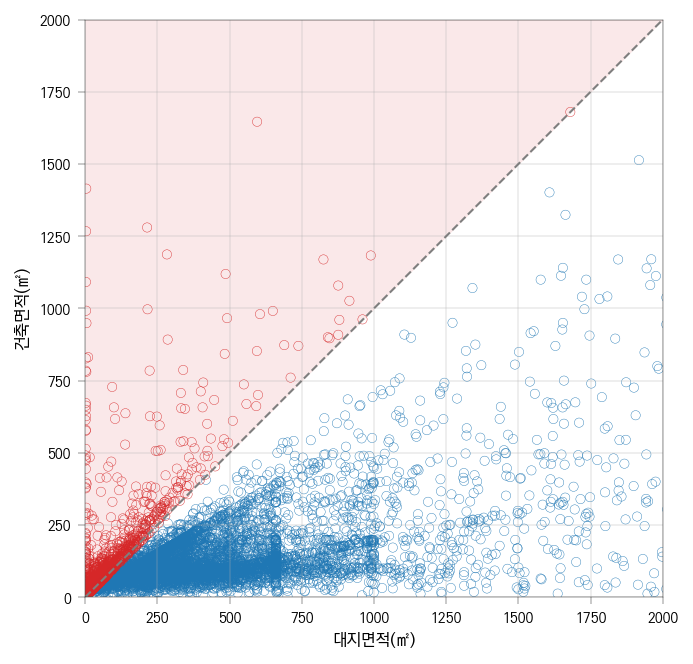

In [ ]:
sampled = stratified_sample(df, "건축_면적_이상", n=10_000, min_per_stratum=1_000)

# Scatterplot of "대지_면적(㎡)" vs "건축_면적(㎡)"
plt.figure(figsize=(5, 5))
colors = sampled["건축_면적_이상"].map({True: "tab:red", False: "tab:blue"})
plt.scatter(
    sampled["대지_면적(㎡)"],
    sampled["건축_면적(㎡)"],
    edgecolors=colors,
    facecolors="none",
    s=20,
)

max_val = sampled["건축_면적(㎡)"].max()
max_val = 2000
plt.xlim(0, max_val)
plt.ylim(0, max_val)

# 45-degree line
plt.plot([0, max_val], [0, max_val], color="tab:gray", linestyle="--", linewidth=1)

# Shade area above the 45-degree line
plt.fill_between(
    [0, max_val],
    [max_val, max_val],
    [0, max_val],
    color="tab:red",
    alpha=0.10,
    zorder=0,
)
# plt.xscale("log")
# plt.yscale("log")

plt.gca().set_aspect("equal")
plt.xlabel("대지면적(㎡)")
plt.ylabel("건축면적(㎡)")
# plt.title("대지 면적과 건축 면적 산점도")
plt.grid(True)

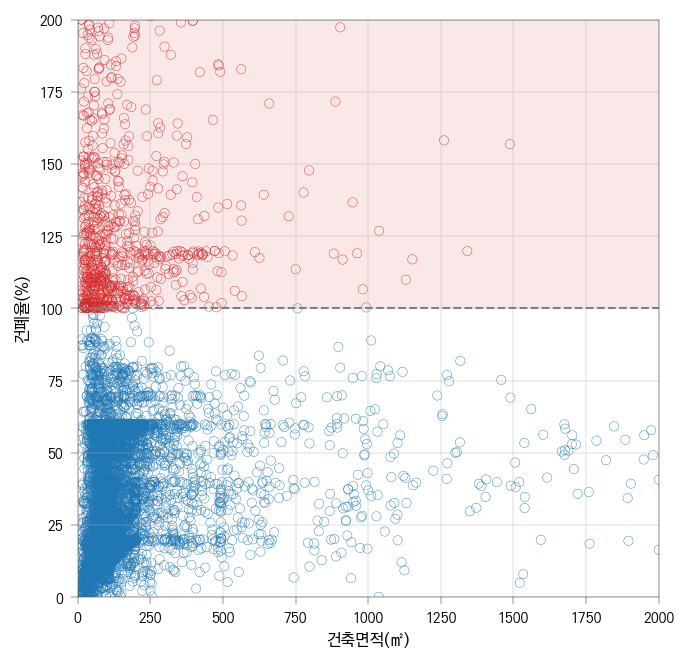

In [ ]:
df["건폐율_이상"] = df["건폐_율(%)"] > 100
sampled = stratified_sample(df, "건폐율_이상", n=10_000, min_per_stratum=1_000)

plt.figure(figsize=(5, 5))
colors = sampled["건폐율_이상"].map({True: "tab:red", False: "tab:blue"})
plt.scatter(
    sampled["건축_면적(㎡)"],
    sampled["건폐_율(%)"],
    edgecolors=colors,
    facecolors="none",
    s=20,
)
max_xval = 2000
max_yval = 200
plt.xlim(0, max_xval)
plt.ylim(0, max_yval)

# line
plt.plot([0, max_xval], [100, 100], color="tab:gray", linestyle="--", linewidth=1)

# Shade area above the line
plt.fill_between(
    [0, max_xval],
    [100, 100],
    [max_yval, max_yval],
    color="tab:red",
    alpha=0.10,
    zorder=0,
)

plt.xlabel("건축면적(㎡)")
plt.ylabel("건폐율(%)")
plt.grid(True)

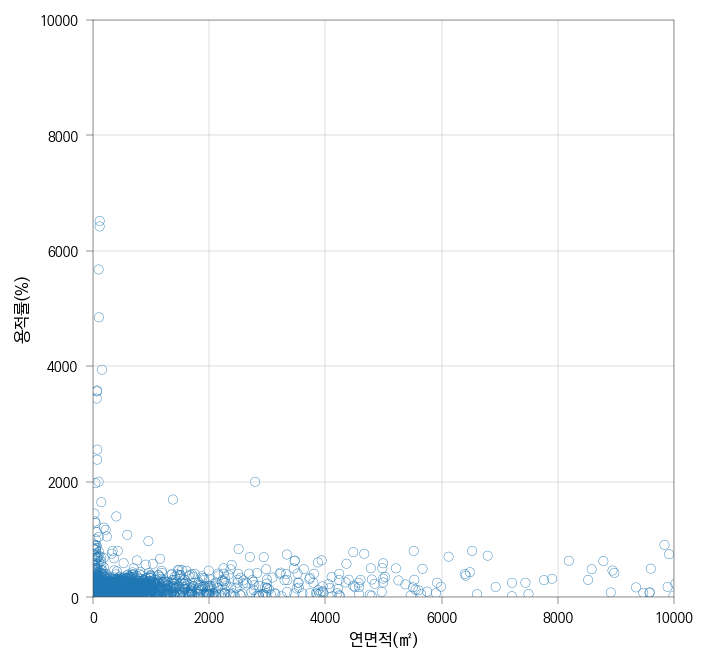

In [ ]:
df["건폐율_이상"] = df["건폐_율(%)"] > 100
sampled = stratified_sample(df, "건폐율_이상", n=10_000, min_per_stratum=1_000)

plt.figure(figsize=(5, 5))
colors = sampled["건폐율_이상"].map({True: "tab:red", False: "tab:blue"})
plt.scatter(
    sampled["연면적(㎡)"],
    sampled["용적_률(%)"],
    # edgecolors=colors,
    edgecolors="tab:blue",
    facecolors="none",
    s=20,
)
max_xval = 10_000
max_yval = 10_000
plt.xlim(0, max_xval)
plt.ylim(0, max_yval)

# line
# plt.plot([0, max_xval], [100, 100], color="tab:gray", linestyle="--", linewidth=1)

# Shade area above the line
# plt.fill_between(
#     [0, max_xval],
#     [100, 100],
#     [max_yval, max_yval],
#     color="tab:red",
#     alpha=0.10,
#     zorder=0,
# )

plt.xlabel("연면적(㎡)")
plt.ylabel("용적률(%)")
plt.grid(True)

In [ ]:
# from sklearn import svm
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest
from sklearn.kernel_approximation import Nystroem
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import make_pipeline

from sklearn.model_selection import train_test_split

from sklearn.inspection import DecisionBoundaryDisplay


(1000, 2) float64


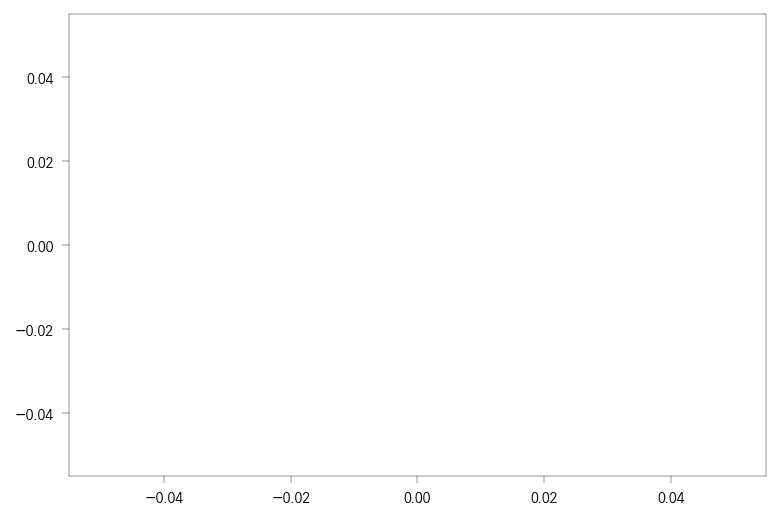

In [ ]:
sampled = df.sample(n=1_000, replace=False, random_state=1106)
X = sampled[["연면적(㎡)", "용적_률(%)"]].values
X_train, X_test = train_test_split(X, test_size=0.2, random_state=1106)

clf = IsolationForest(random_state=1106)
clf.fit(X_train)

print(X.shape, X.dtype)


disp = DecisionBoundaryDisplay.from_estimator(
    clf,
    X,
    alpha=0.5,
)

(280, 2) float64


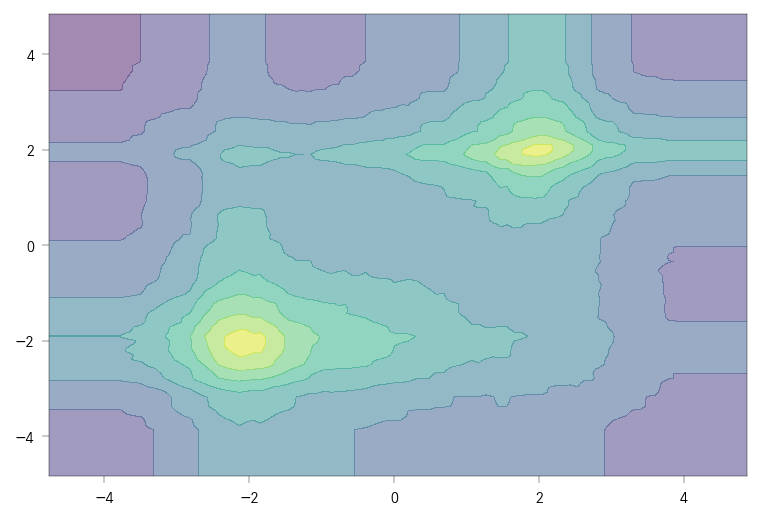

In [ ]:
import numpy as np

from sklearn.model_selection import train_test_split

n_samples, n_outliers = 120, 40
rng = np.random.RandomState(0)
covariance = np.array([[0.5, -0.1], [0.7, 0.4]])
cluster_1 = 0.4 * rng.randn(n_samples, 2) @ covariance + np.array([2, 2])  # general
cluster_2 = 0.3 * rng.randn(n_samples, 2) + np.array([-2, -2])  # spherical
outliers = rng.uniform(low=-4, high=4, size=(n_outliers, 2))

X = np.concatenate([cluster_1, cluster_2, outliers])
print(X.shape, X.dtype)

X_train, X_test = train_test_split(X, random_state=42)

from sklearn.ensemble import IsolationForest

clf = IsolationForest(max_samples=100, random_state=0)
clf.fit(X_train)

disp = DecisionBoundaryDisplay.from_estimator(
    clf,
    X,
    response_method="decision_function",
    alpha=0.5,
)
# scatter = disp.ax_.scatter(X[:, 0], X[:, 1], s=20, edgecolor="k")
# disp.ax_.set_title("Path length decision boundary \nof IsolationForest")
# plt.axis("square")
# plt.colorbar(disp.ax_.collections[1])
# plt.show()